## 1. Setup

In [1]:
import torch, os
import numpy as np
import torch.nn as nn
print("PyTorch:", torch.__version__, "| CUDA:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import importlib, subprocess, sys
for pkg,pip in [("skimage","scikit-image"),("cv2","opencv-python-headless"),("matplotlib","matplotlib")]:
    if importlib.util.find_spec(pkg) is None:
        subprocess.run([sys.executable,"-m","pip","install","-q",pip])
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import cv2, matplotlib.pyplot as plt
print("deps ready")

PyTorch: 2.11.0+cu128 | CUDA: True
deps ready


## 2. Upload blind checkpoint

In [2]:
CKPT = "model_030.pth"
if not os.path.exists(CKPT):
    try:
        from google.colab import files
        print("Upload model_030.pth (blind, depth 20) ...")
        up = files.upload()
        if CKPT not in up:
            pths = [k for k in up if k.endswith(".pth")]
            if pths: CKPT = pths[0]
    except Exception as e:
        print("Manual upload needed.", e)
assert os.path.exists(CKPT), "Upload the blind checkpoint first."
print("Using checkpoint:", CKPT)

Using checkpoint: model_030.pth


## 3. Build the depth-20 BatchNorm model and load weights


In [3]:
class DnCNN(nn.Module):
    def __init__(self, depth=20, n_channels=64, image_channels=1, kernel_size=3):
        super().__init__()
        pad = kernel_size//2
        layers = [nn.Conv2d(image_channels, n_channels, kernel_size, padding=pad, bias=True),
                  nn.ReLU(inplace=True)]
        for _ in range(depth-2):
            layers += [nn.Conv2d(n_channels, n_channels, kernel_size, padding=pad, bias=False),
                       nn.BatchNorm2d(n_channels, eps=1e-4, momentum=0.95),
                       nn.ReLU(inplace=True)]
        layers += [nn.Conv2d(n_channels, image_channels, kernel_size, padding=pad, bias=False)]
        self.dncnn = nn.Sequential(*layers)
    def forward(self, x):
        return x - self.dncnn(x)

state = torch.load(CKPT, map_location=device)
if isinstance(state, dict) and "state_dict" in state:
    state = state["state_dict"]

# auto-detect depth = number of 4-D conv weight tensors
depth = sum(1 for k,v in state.items() if k.endswith(".weight") and v.dim()==4) if isinstance(state, dict) else 20
print("Detected depth:", depth)

model = DnCNN(depth=depth).to(device)
missing, unexpected = model.load_state_dict(state, strict=False)
print(f"Loaded | missing {len(missing)} | unexpected {len(unexpected)}")
if missing:    print("  missing e.g.:", missing[:4])
if unexpected: print("  unexpected e.g.:", unexpected[:4])
model.eval()   # CRITICAL: BatchNorm uses stored running stats
print("Blind model ready, eval mode.")

Detected depth: 20
Loaded | missing 0 | unexpected 0
Blind model ready, eval mode.


## 4. Load Set12

In [4]:
import urllib.request
os.makedirs("Set12", exist_ok=True)
base = "https://raw.githubusercontent.com/cszn/DnCNN/master/testsets/Set12"
imgs = []
for n in range(1,13):
    p = f"Set12/{n:02d}.png"
    if not os.path.exists(p):
        try: urllib.request.urlretrieve(f"{base}/{n:02d}.png", p)
        except Exception as e: print("dl fail", n, e)
    if os.path.exists(p):
        imgs.append(cv2.imread(p,0).astype("float32")/255.0)
print("Set12 images:", len(imgs))

Set12 images: 12


## 5. Evaluate the blind model across noise levels


In [5]:
@torch.no_grad()
def denoise(clean, sigma, seed=0):
    rng = np.random.default_rng(seed)
    noisy = clean + rng.normal(0, sigma/255.0, clean.shape)
    t = torch.from_numpy(noisy).float().unsqueeze(0).unsqueeze(0).to(device)
    den = model(t).squeeze().cpu().numpy()
    return np.clip(noisy,0,1), np.clip(den,0,1)
def metrics(c,t): return psnr(c,t,data_range=1.0), ssim(c,t,data_range=1.0)

REF = {15:32.86, 25:30.44, 50:27.18}
print(f"{'sigma':>6} | {'blind PSNR':>11} | {'blind SSIM':>11} | {'matched ref':>11} | gap")
print("-"*58)
results = {}
for sigma in [15,25,50]:
    ps, ss = [], []
    for k,clean in enumerate(imgs):
        _, den = denoise(clean, sigma, seed=k)
        p,s = metrics(clean, den); ps.append(p); ss.append(s)
    mp, msd = float(np.mean(ps)), float(np.mean(ss))
    results[sigma] = (mp, msd)
    print(f"{sigma:>6} | {mp:>11.2f} | {msd:>11.3f} | {REF[sigma]:>11.2f} | {mp-REF[sigma]:+.2f}")

 sigma |  blind PSNR |  blind SSIM | matched ref | gap
----------------------------------------------------------
    15 |       32.44 |       0.890 |       32.86 | -0.42
    25 |       30.18 |       0.850 |       30.44 | -0.26
    50 |       26.97 |       0.762 |       27.18 | -0.21


## 6. Visual check at each noise level

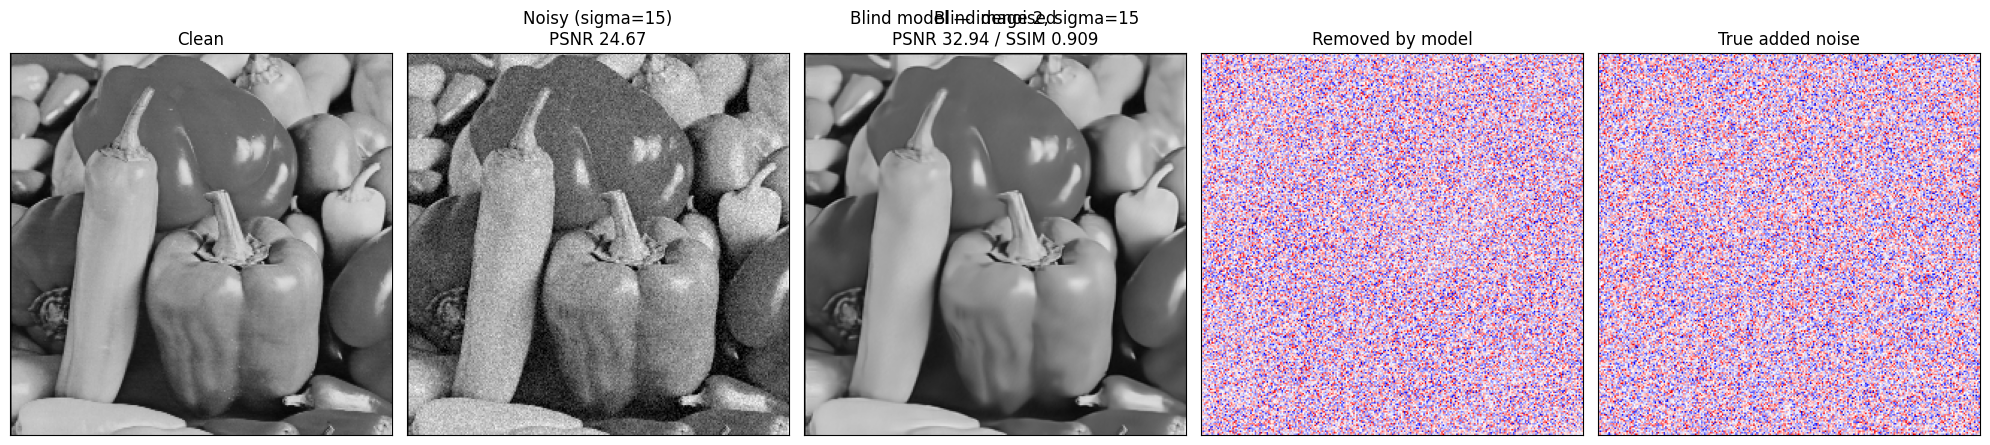

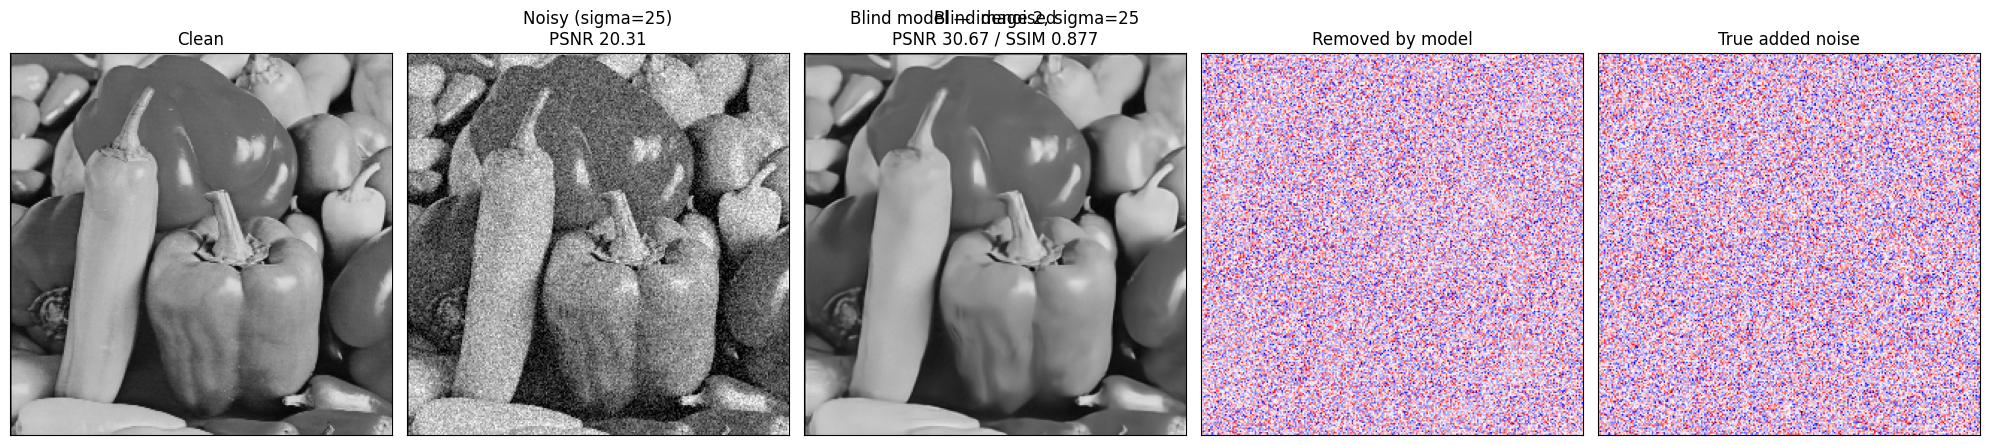

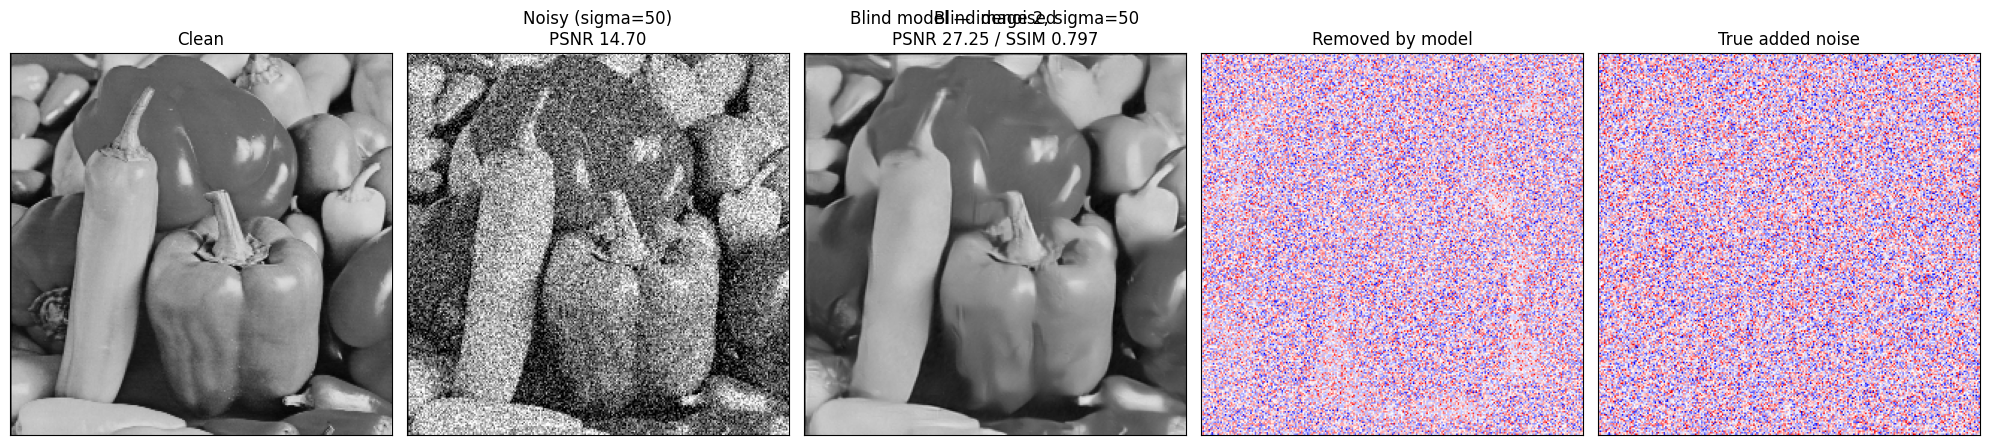

In [6]:
def show(idx, sigma, seed=0):
    clean = imgs[idx]
    rng = np.random.default_rng(seed)
    true_noise = rng.normal(0, sigma/255.0, clean.shape)
    noisy, den = denoise(clean, sigma, seed)
    removed = noisy - den
    p_n,_ = metrics(clean, noisy); p_d,s_d = metrics(clean, den)
    lim = max(abs(removed).max(), abs(true_noise).max())
    fig, ax = plt.subplots(1,5, figsize=(20,4.5))
    ax[0].imshow(clean, cmap="gray", vmin=0, vmax=1); ax[0].set_title("Clean")
    ax[1].imshow(noisy, cmap="gray", vmin=0, vmax=1); ax[1].set_title(f"Noisy (sigma={sigma})\nPSNR {p_n:.2f}")
    ax[2].imshow(den, cmap="gray", vmin=0, vmax=1);   ax[2].set_title(f"Blind denoised\nPSNR {p_d:.2f} / SSIM {s_d:.3f}")
    ax[3].imshow(removed, cmap="seismic", vmin=-lim, vmax=lim); ax[3].set_title("Removed by model")
    ax[4].imshow(true_noise, cmap="seismic", vmin=-lim, vmax=lim); ax[4].set_title("True added noise")
    for a in ax: a.set_xticks([]); a.set_yticks([])
    plt.suptitle(f"Blind model — image {idx}, sigma={sigma}", fontsize=12)
    plt.tight_layout(); plt.show()

# one image at each of the three levels
show(2, 15); show(2, 25); show(2, 50)

## 7. Training curves (reconstructed from the log)


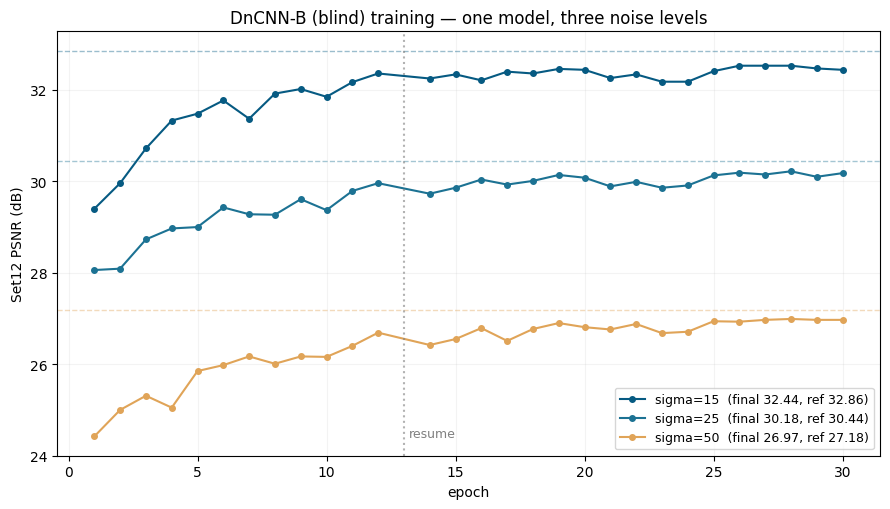

Final blind PSNR (epoch 30): {15: 32.44, 25: 30.18, 50: 26.97}
Matched references          : {15: 32.86, 25: 30.44, 50: 27.18}
Gap to specialists          : {15: -0.42, 25: -0.26, 50: -0.21}


In [8]:
import matplotlib.pyplot as plt

# --- Per-epoch Set12 PSNR, transcribed from the training log (epochs 1-30) ---
# Columns in the log were:  PSNR  15:..  25:..  50:..
# Epoch 13 was the resume point and was not printed, so it is left as None (gap in the line).
# These are read from the screenshots; correct any value against your own log if needed.
epoch = list(range(1,31))

p15 = [29.40,29.96,30.72,31.33,31.48,31.77,31.37,31.92,32.02,31.85,32.17,32.36, None,
       32.25,32.34,32.21,32.40,32.36,32.46,32.44,32.26,32.34,32.18,32.18,32.41,32.53,32.53,32.53, 32.47,32.44]
p25 = [28.06,28.09,28.73,28.97,29.00,29.43,29.28,29.27,29.61,29.37,29.79,29.96, None,
       29.73,29.86,30.04,29.93,30.01,30.14,30.08,29.89,29.99,29.86,29.91,30.13,30.19,30.15,30.22, 30.10,30.18]
p50 = [24.42,25.00,25.31,25.05,25.85,25.98,26.17,26.01,26.17,26.16,26.40,26.69, None,
       26.42,26.55,26.79,26.51,26.77,26.90,26.81,26.76,26.88,26.68,26.71,26.94,26.93,26.97,26.99, 26.97,26.97]

REF = {15:32.86, 25:30.44, 50:27.18}

def clean_xy(ys):
    xs=[e for e,y in zip(epoch,ys) if y is not None]
    yy=[y for y in ys if y is not None]
    return xs, yy

fig, ax = plt.subplots(figsize=(9,5.2))
for ys, col, sig in [(p15,"#065A82",15),(p25,"#1C7293",25),(p50,"#E0A458",50)]:
    xs,yy = clean_xy(ys)
    ax.plot(xs, yy, marker="o", ms=4, color=col, label=f"sigma={sig}  (final {yy[-1]:.2f}, ref {REF[sig]})")
    ax.axhline(REF[sig], ls="--", lw=1, c=col, alpha=0.4)
ax.axvline(13, ls=":", c="grey", alpha=0.6)
ax.text(13.2, ax.get_ylim()[0]+0.4, "resume", color="grey", fontsize=9)
ax.set_xlabel("epoch"); ax.set_ylabel("Set12 PSNR (dB)")
ax.set_title("DnCNN-B (blind) training — one model, three noise levels")
ax.legend(loc="lower right", fontsize=9); ax.grid(alpha=0.15)
plt.tight_layout(); plt.show()

print("Final blind PSNR (epoch 30):", {15:p15[-1],25:p25[-1],50:p50[-1]})
print("Matched references          :", REF)
print("Gap to specialists          :", {s: round({15:p15,25:p25,50:p50}[s][-1]-REF[s],2) for s in (15,25,50)})